In [14]:
import pandas as pd
import os
import re

In [15]:
dir  = fr"C:\PROJECT-DEMETER\Demeter-LSTM_AE\Result Files\Z-factor-files"

In [16]:

mode = "all"  # dynamically set in your actual script

# === COMBINE ONLY IF MODE == "all" ===
if mode == "all":
    alldf = []

    for file in os.listdir(dir):
        if file.endswith("_newz.csv") and  file.startswith("Q") and "all" in file:
            print(f"[LOAD] {file}")

            # Extract label from filename, e.g. "Qfactor-SW22x22_TW6-all.csv" → "SW22x22_TW6"
            parts = file.replace(".csv", "").split("-")
            label_name = parts[1] if len(parts) > 1 else "unknown"

            # Read CSV
            df = pd.read_csv(os.path.join(dir, file))

            # Add new column with label info
            df["label_name"] = label_name

            # Keep a record of this info
            print(f"  → Added label_name = '{label_name}'")

            alldf.append(df)

    if alldf:
        combined_df = pd.concat(alldf, ignore_index=True)

        out_path = os.path.join(dir, "combined_output_all.csv")
        combined_df.to_csv(out_path, index=False)

        print(f"\n✅ Combined CSV saved to {out_path}")
        print(f"✅ Total rows: {len(combined_df):,}")
        print(f"✅ Unique label_names: {combined_df['label_name'].nunique()}")
    else:
        print("⚠️ No matching '_all_' CSV files found in directory.")
else:
    print("ℹ️ Mode is not 'all' — skipping CSV combination.")


[LOAD] Qfactor-SW05x05_WG_TW48-all_newz.csv
  → Added label_name = 'SW05x05_WG_TW48'
[LOAD] Qfactor-SW10x10_gap_TW48-all_newz.csv
  → Added label_name = 'SW10x10_gap_TW48'
[LOAD] Qfactor-SW10x10_WG_TW48-all_newz.csv
  → Added label_name = 'SW10x10_WG_TW48'
[LOAD] Qfactor-SW10x10_WOG_TW48-all_newz.csv
  → Added label_name = 'SW10x10_WOG_TW48'
[LOAD] Qfactor-SW20x20_TW48-all_newz.csv
  → Added label_name = 'SW20x20_TW48'
[LOAD] Qfactor-SW20x20_WOG_TW48-all_newz.csv
  → Added label_name = 'SW20x20_WOG_TW48'
[LOAD] Qfactor-SW22x22_TW12-all_newz.csv
  → Added label_name = 'SW22x22_TW12'
[LOAD] Qfactor-SW22x22_TW24-all_newz.csv
  → Added label_name = 'SW22x22_TW24'
[LOAD] Qfactor-SW22x22_TW48-all_newz.csv
  → Added label_name = 'SW22x22_TW48'
[LOAD] Qfactor-SW22x22_TW6-all_newz.csv
  → Added label_name = 'SW22x22_TW6'
[LOAD] Qfactor-SW23x20_TW48-all_newz.csv
  → Added label_name = 'SW23x20_TW48'

✅ Combined CSV saved to C:\PROJECT-DEMETER\Demeter-LSTM_AE\Result Files\Z-factor-files\combined_

In [17]:
combined_df = pd.read_csv(os.path.join(dir, "combined_output_all_SW.csv"))

In [18]:
df = combined_df

In [19]:
df['z_va_score'] =df['z_va_all']

# Higher score = better: high z_va, small errors
ranked = df.sort_values('z_va_score', ascending=False)

# Top N candidates
top5 = ranked.head(5)[['Naming','label_name', 'z_va_all', 'z_va_err32_all', 'z_va_err68_all', 'z_va_score']]
print(top5)


                    Naming        label_name  z_va_all  z_va_err32_all  \
64            tw48-30dBG_E  SW22x22_WOG_TW48  1.268752        1.768752   
42            tw48-30dBG_C   SW20x20_WG_TW48  1.168231        0.390847   
68         tw48-30dBG_In-D  SW22x22_WOG_TW48  1.144518        1.854949   
76  SW2023-tw48-30dBG_In-B  SW23x20_WOG_TW48  1.122014        0.602574   
73     SW2023-tw48-30dBG_D  SW23x20_WOG_TW48  1.111820        0.300258   

    z_va_err68_all  z_va_score  
64        2.951503    1.268752  
42        2.028509    1.168231  
68        3.017082    1.144518  
76        1.348625    1.122014  
73        1.694433    1.111820  


In [20]:
import numpy as np

k = 15

score_thresh = 3/ np.sqrt(k)   # ≈ 0.7746 if z_va_score is an avg z


In [21]:
score_thresh

0.7745966692414834

In [22]:
df['z_va_score'] = df['z_va_all']


In [23]:
# Filter models above the threshold
above = df[df['z_va_score'] > score_thresh]

# Count per label_name
counts_above = (
    above
    .groupby('label_name')
    .size()
    .reset_index(name='n_models_above_thresh')
)

print(counts_above)


         label_name  n_models_above_thresh
0   SW10x10_WG_TW48                      2
1   SW20x20_WG_TW48                      4
2  SW22x22_WOG_TW48                      7
3  SW23x20_WOG_TW48                      6


In [24]:
# total models per label
total_per_label = (
    df.groupby('label_name')
      .size()
      .reset_index(name='n_total_models')
)

# merge with counts above threshold
summary = total_per_label.merge(counts_above, on='label_name', how='left')
summary['n_models_above_thresh'] = summary['n_models_above_thresh'].fillna(0).astype(int)

# proportion of good models per label
summary['prop_above_thresh'] = summary['n_models_above_thresh'] / summary['n_total_models']

print(summary)


         label_name  n_total_models  n_models_above_thresh  prop_above_thresh
0   SW05x05_WG_TW48              10                      0                0.0
1   SW10x10_WG_TW48              10                      2                0.2
2  SW10x10_WOG_TW48              10                      0                0.0
3  SW10x10_gap_TW48              10                      0                0.0
4   SW20x20_WG_TW48              10                      4                0.4
5  SW20x20_WOG_TW48              10                      0                0.0
6  SW22x22_WOG_TW48              10                      7                0.7
7  SW23x20_WOG_TW48              10                      6                0.6


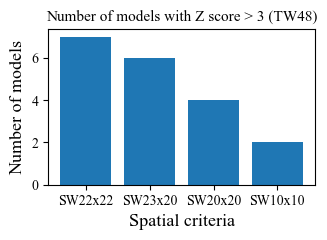

In [25]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# -----------------------------
# Figure / font configuration
# -----------------------------
mpl.rcParams.update({

    "font.family": "serif",
    "font.serif": ["Times New Roman"],


})

# --------------------------------------
# Make a 1-column AGU-style bar figure
# --------------------------------------
# AGU one-column figures are ~50–85 mm wide → use 85 mm ≈ 3.35 in wide
fig_width_in = 3.35  # inches
fig_height_in = 2.5  # adjust as needed

# Sort by count for nicer visuals
counts_above_sorted = counts_above.sort_values(
    "n_models_above_thresh",
    ascending=False
)

fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in))
counts_above_sorted["label_name_N"] = counts_above_sorted["label_name"].str.split("_").str[0]

ax.bar(
    counts_above_sorted["label_name_N"],
    counts_above_sorted["n_models_above_thresh"]
)
ax.set_xlabel("Spatial criteria",fontsize=13)
ax.set_ylabel("Number of models",fontsize=13)
ax.set_title("Number of models with Z score > 3 (TW48)", fontsize=11)

# Rotate x labels for readability
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

# Make layout tight for export
fig.tight_layout()

# Save at publication quality (PNG/EPS/TIFF as needed)
# For submission you might prefer EPS or TIFF:
# fig.savefig("fig_high_scoring_models.eps", bbox_inches="tight")
# fig.savefig("C:\PROJECT-DEMETER\Paper1\Plots\\IEEE\\fig_7a.png", bbox_inches="tight", dpi=600)
# fig.savefig("C:\PROJECT-DEMETER\Paper1\Plots\\IEEE\\fig_7a.eps", bbox_inches="tight", dpi=600)
plt.show()


             Naming        label_name  z_va_all  z_va_err32_all  \
24     tw48-30dBG_E  SW22x22_WOG_TW48  1.268752        1.768752   
28  tw48-30dBG_In-D  SW22x22_WOG_TW48  1.144518        1.854949   
11     tw24-30dBG_B  SW22x22_WOG_TW24  1.071646        0.492916   
22     tw48-30dBG_C  SW22x22_WOG_TW48  1.036936        1.999174   
10     tw24-30dBG_A  SW22x22_WOG_TW24  0.974047        0.536258   

    z_va_err68_all  z_va_score  
24        2.951503    1.268752  
28        3.017082    1.144518  
11        1.774566    1.071646  
22        3.337975    1.036936  
10        1.572226    0.974047  
         label_name  n_models_above_thresh
0  SW22x22_WOG_TW24                      4
1  SW22x22_WOG_TW48                      7
         label_name  n_total_models  n_models_above_thresh  prop_above_thresh
0  SW22x22_WOG_TW12              10                      0                0.0
1  SW22x22_WOG_TW24              10                      4                0.4
2  SW22x22_WOG_TW48              10 

C:\Users\mbabu\AppData\Local\Temp\ipykernel_31368\1844039844.py:98: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


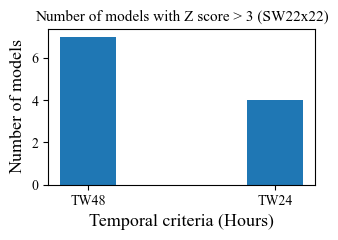

In [26]:
combined_df = pd.read_csv(os.path.join(dir, "combined_output_all_TW.csv"))
combined_df
df = combined_df
df['z_va_score'] =df['z_va_all']

# Higher score = better: high z_va, small errors
ranked = df.sort_values('z_va_score', ascending=False)

# Top N candidates
top5 = ranked.head(5)[['Naming','label_name', 'z_va_all', 'z_va_err32_all', 'z_va_err68_all', 'z_va_score']]
print(top5)

import numpy as np

k = 15

score_thresh = 3/ np.sqrt(k)   # ≈ 0.7746 if z_va_score is an avg z

df['z_va_score'] = df['z_va_all']

# Filter models above the threshold
above = df[df['z_va_score'] > score_thresh]

# Count per label_name
counts_above = (
    above
    .groupby('label_name')
    .size()
    .reset_index(name='n_models_above_thresh')
)

print(counts_above)

# total models per label
total_per_label = (
    df.groupby('label_name')
      .size()
      .reset_index(name='n_total_models')
)

# merge with counts above threshold
summary = total_per_label.merge(counts_above, on='label_name', how='left')
summary['n_models_above_thresh'] = summary['n_models_above_thresh'].fillna(0).astype(int)

# proportion of good models per label
summary['prop_above_thresh'] = summary['n_models_above_thresh'] / summary['n_total_models']

print(summary)

import matplotlib as mpl
import matplotlib.pyplot as plt

# -----------------------------
# Figure / font configuration
# -----------------------------
mpl.rcParams.update({

    "font.family": "serif",
    "font.serif": ["Times New Roman"],


})

# --------------------------------------
# Make a 1-column AGU-style bar figure
# --------------------------------------
# AGU one-column figures are ~50–85 mm wide → use 85 mm ≈ 3.35 in wide
fig_width_in = 3.35  # inches
fig_height_in = 2.5  # adjust as needed

# Sort by count for nicer visuals
counts_above_sorted = counts_above.sort_values(
    "n_models_above_thresh", ascending=False
)

# Shorten labels: first 2 components split by "_"
counts_above_sorted["label_name_short"] = (
    counts_above_sorted["label_name"]
    .str.split("_")
    .str[-1]

)

fig, ax = plt.subplots(figsize=(fig_width_in, fig_height_in), constrained_layout=True)

ax.bar(
    counts_above_sorted["label_name_short"],
    counts_above_sorted["n_models_above_thresh"],  width=0.3
)

ax.set_xlabel("Temporal criteria (Hours)", fontsize=13)
ax.set_ylabel("Number of models", fontsize=13)
ax.set_title("Number of models with Z score > 3 (SW22x22)", fontsize=11)
# Rotate x labels for readability
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

# Make layout tight for export
fig.tight_layout()

# Save at publication quality (PNG/EPS/TIFF as needed)
# For submission you might prefer EPS or TIFF:
# fig.savefig("fig_high_scoring_models.eps", bbox_inches="tight")
# fig.savefig("C:\PROJECT-DEMETER\Paper1\Plots\\IEEE\\fig_7b.png", bbox_inches="tight", dpi=300)
# fig.savefig("C:\PROJECT-DEMETER\Paper1\Plots\\IEEE\\fig_7b.eps", bbox_inches="tight", dpi=300)
plt.show()
